#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing packages for the GBMs.

In [19]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

Importing the California house dataset.

In [16]:
data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

models = {
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbose=0)
}

Fitting the models.

In [ ]:
stats = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    duration = time.time() - t0

    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    stats.append({"Model": name, "Time (s)": duration, "RMSE": rmse})

Plotting the training time and Root Mean Squared Error (RMSE).

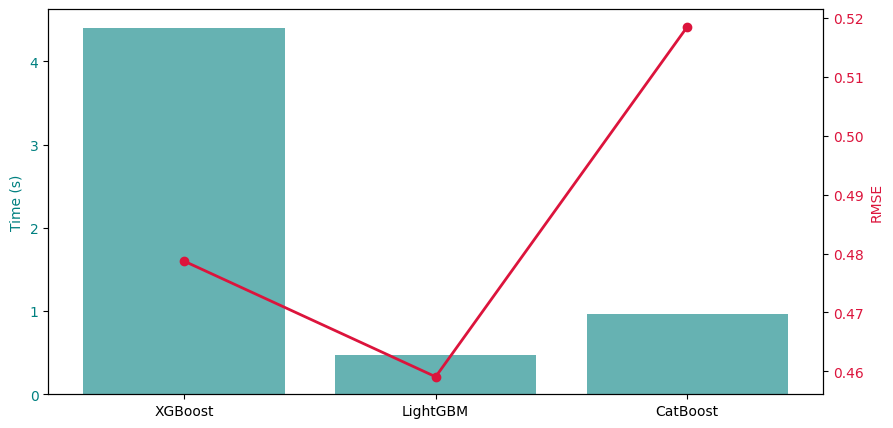

In [20]:
df_stats = pd.DataFrame(stats)
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(df_stats['Model'], df_stats['Time (s)'], color='teal', alpha=0.6, label='Training Time')
ax1.set_ylabel('Time (s)', color='teal')
ax1.tick_params(axis='y', labelcolor='teal')

ax2 = ax1.twinx()
ax2.plot(df_stats['Model'], df_stats['RMSE'], color='crimson', marker='o', linewidth=2, label='RMSE')
ax2.set_ylabel('RMSE', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.show()